# Exercises XP Ninja: Guided Student Notebook

This guided notebook follows the **exact exercise on the platform**. Cells marked **PREFILLED** are for execution only. Cells marked **To-Do** require your action. When a written answer is required, the **To-Do** appears inside a markdown cell. When code is required, the **To-Do** appears inside a code cell as comments.

Learning points are included only when a concept is important for intuition or transfer to other AI topics.


## Reference from the exercise

**What you will learn**  
- How to implement a deep neural network from scratch.
- How to optimize weight updates using advanced backpropagation techniques.
- How to fine tune hyperparameters and activation functions for better model performance.

**What you will create**  
- A fully connected deep neural network without using high level deep learning libraries.
- A manual backpropagation algorithm with vectorized computations.
- A neural network that learns through an optimized training loop.


## Exercise 1: Building a Deep Neural Network Without Keras or TensorFlow

**As stated in the exercise**  
Task: Implement a fully connected deep neural network from scratch using only NumPy. The model has three layers input, two hidden, and output. Use the ReLU activation function for hidden layers and Softmax for multi class classification. Compute both forward and backward propagation manually.  
Given data. Input features are a dataset with four numerical features. Number of classes is three. Number of hidden neurons is five for the first hidden layer and four for the second hidden layer. Learning rate is 0.01.

Steps: Initialize weights and biases for all layers. Implement forward propagation. Implement the Softmax function for the output layer. Compute the loss using categorical cross entropy. Implement backpropagation using matrix operations. Update weights and biases using gradient descent. Train the network for multiple iterations and evaluate performance.

**Guidance**  
Work with shapes. X is (N, 4). One hot targets Y are (N, 3). Parameter shapes: W1 (4, 5), b1 (5,), W2 (5, 4), b2 (4,), W3 (4, 3), b3 (3,). Use stable Softmax with logits shift by max per row. For cross entropy, average negative log likelihood over the batch.

**Learning point**  
Softmax plus cross entropy has a compact gradient: dZ3 equals Yhat minus Y. ReLU derivative is 1 on positives and 0 on non positives. Vectorize all operations to avoid slow loops.


In [5]:
# PREFILLED: just execute
import numpy as np

rng = np.random.default_rng(123)

# Synthetic dataset generator for 3 classes in 4D
def make_blob_4d(n_per_class=200, spread=0.8):
    centers = np.array([
        [ 2.0,  2.0,  0.0,  0.5],
        [-2.0,  1.5,  1.0, -0.5],
        [ 0.0, -2.0, -1.5,  1.0],
    ])
    X_list, y_list = [], []
    for k, c in enumerate(centers):
        Xk = rng.normal(loc=c, scale=spread, size=(n_per_class, 4))
        yk = np.full(n_per_class, k, dtype=int)
        X_list.append(Xk); y_list.append(yk)
    X = np.vstack(X_list)
    y = np.concatenate(y_list)
    # shuffle
    idx = rng.permutation(len(y))
    return X[idx], y[idx]

# Train and test split
X_all, y_all = make_blob_4d(n_per_class=150, spread=0.9)
N = X_all.shape[0]
split = int(0.8 * N)
X_train, y_train = X_all[:split], y_all[:split]
X_test,  y_test  = X_all[split:], y_all[split:]

# One hot
def one_hot(y, num_classes=3):
    Y = np.zeros((y.shape[0], num_classes), dtype=float)
    Y[np.arange(y.shape[0]), y] = 1.0
    return Y

Y_train = one_hot(y_train, 3)
Y_test  = one_hot(y_test, 3)

X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((360, 4), (360, 3), (90, 4), (90, 3))

In [6]:
# PREFILLED: just execute
# Standardize inputs to zero mean unit variance for stable training
mu = X_train.mean(axis=0, keepdims=True)
sd = X_train.std(axis=0, keepdims=True) + 1e-8
X_train_std = (X_train - mu) / sd
X_test_std  = (X_test  - mu) / sd

print("Means:", mu.ravel())
print("Stds:", sd.ravel())

Means: [-0.01314787  0.48525324 -0.06843803  0.31093986]
Stds: [1.93296348 1.98620559 1.38844722 1.07442903]


In [1]:
def relu(x):
    return np.maximum(0.0, x)
def drelu(x):
    return (x > 0).astype(float)
def softmax(logits):
    # subtract rowwise max for numerical stability, then exponentiate and normalize
    shiftx = logits - np.max(logits, axis=1, keepdims=True)
    exp_x = np.exp(shiftx)
    return exp_x / np.sum(exp_x, axis=1, keepdims=True)
def cross_entropy(probs, Y_true):
    # average negative log likelihood
    N = probs.shape[0]
    # Clip probabilities to avoid log(0)
    probs = np.clip(probs, 1e-12, 1 - 1e-12)
    loss = -np.sum(Y_true * np.log(probs)) / N
    # return scalar loss
    return loss

In [7]:
# PREFILLED: just execute
D, H1, H2, C = 4, 5, 4, 3
lr = 0.01

# He initialization for ReLU layers, Xavier for output
W1 = rng.normal(0.0, np.sqrt(2.0/D), size=(D, H1)); b1 = np.zeros(H1)
W2 = rng.normal(0.0, np.sqrt(2.0/H1), size=(H1, H2)); b2 = np.zeros(H2)
W3 = rng.normal(0.0, np.sqrt(1.0/H2), size=(H2, C));  b3 = np.zeros(C)

params = dict(W1=W1, b1=b1, W2=W2, b2=b2, W3=W3, b3=b3)

for k,v in params.items():
    if k.startswith('W'):
        print(k, v.shape)

W1 (4, 5)
W2 (5, 4)
W3 (4, 3)


In [2]:
def forward(X, params):
    W1, b1 = params['W1'], params['b1']
    W2, b2 = params['W2'], params['b2']
    W3, b3 = params['W3'], params['b3']

    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)
    Z3 = A2 @ W3 + b3
    Yhat = softmax(Z3)

    return {"Z1": Z1, "A1": A1, "Z2": Z2, "A2": A2, "Z3": Z3, "Yhat": Yhat}

In [3]:
def backward(X, Y, cache, params):
    N = X.shape[0]
    W1, b1 = params['W1'], params['b1']
    W2, b2 = params['W2'], params['b2']
    W3, b3 = params['W3'], params['b3']
    Z1, A1, Z2, A2, Yhat = cache['Z1'], cache['A1'], cache['Z2'], cache['A2'], cache['Yhat']

    dZ3 = Yhat - Y
    dW3 = A2.T @ dZ3 / N
    db3 = dZ3.mean(axis=0)

    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * drelu(Z2)
    dW2 = A1.T @ dZ2 / N
    db2 = dZ2.mean(axis=0)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * drelu(Z1)
    dW1 = X.T @ dZ1 / N
    db1 = dZ1.mean(axis=0)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2, "dW3": dW3, "db3": db3}

In [9]:
# PREFILLED: just execute
def sgd_update(params, grads, lr):
    for k in ['W1','b1','W2','b2','W3','b3']:
        params[k] = params[k] - lr * grads['d'+k]
    return params

In [10]:
def accuracy(probs, Y_true):
    yhat = probs.argmax(axis=1)
    ytrue = Y_true.argmax(axis=1)
    return (yhat == ytrue).mean()

losses = []
acc_train_hist = []
acc_test_hist = []

epochs = 200
for t in range(epochs):
    cache = forward(X_train_std, params)
    loss = cross_entropy(cache['Yhat'], Y_train)
    grads = backward(X_train_std, Y_train, cache, params)
    params = sgd_update(params, grads, lr)

    losses.append(loss)

    cache_train = forward(X_train_std, params)
    acc_tr = accuracy(cache_train['Yhat'], Y_train)
    acc_train_hist.append(acc_tr)

    cache_test = forward(X_test_std, params)
    acc_te = accuracy(cache_test['Yhat'], Y_test)
    acc_test_hist.append(acc_te)

    if (t+1) % 20 == 0:
        print(f"epoch={t+1} loss={loss:.4f} acc_train={acc_tr:.3f} acc_test={acc_te:.3f}")

epoch=20 loss=1.1961 acc_train=0.403 acc_test=0.389
epoch=40 loss=1.0573 acc_train=0.481 acc_test=0.467
epoch=60 loss=0.9614 acc_train=0.586 acc_test=0.578
epoch=80 loss=0.8876 acc_train=0.689 acc_test=0.689
epoch=100 loss=0.8294 acc_train=0.719 acc_test=0.722
epoch=120 loss=0.7800 acc_train=0.731 acc_test=0.733
epoch=140 loss=0.7357 acc_train=0.742 acc_test=0.733
epoch=160 loss=0.6954 acc_train=0.764 acc_test=0.733
epoch=180 loss=0.6587 acc_train=0.778 acc_test=0.756
epoch=200 loss=0.6255 acc_train=0.786 acc_test=0.778


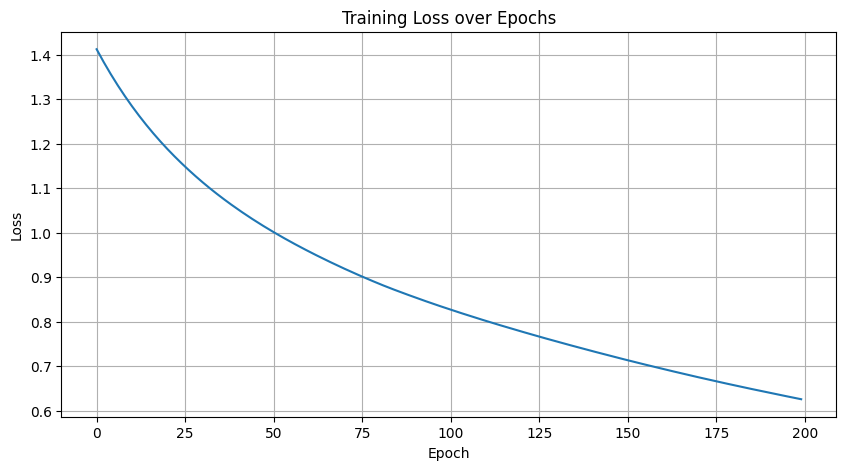

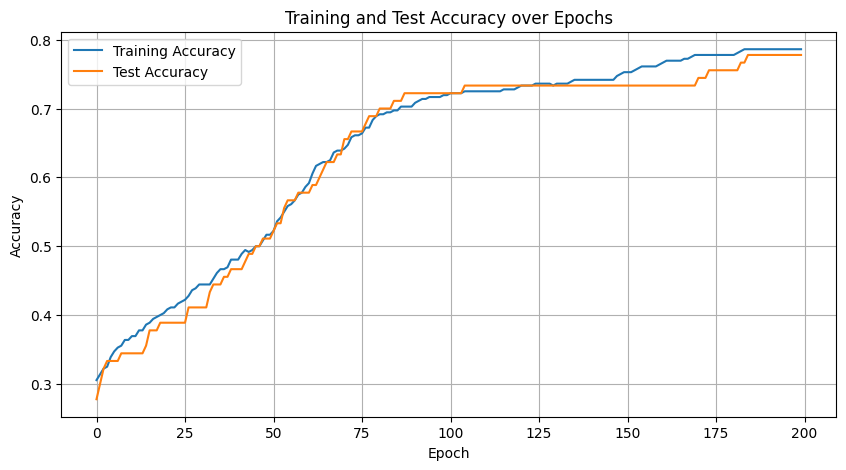

In [11]:
import matplotlib.pyplot as plt

# Plotting the training loss
plt.figure(figsize=(10, 5))
plt.plot(losses)
plt.title('Training Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.grid(True)
plt.show()

# Plotting the training and test accuracy
plt.figure(figsize=(10, 5))
plt.plot(acc_train_hist, label='Training Accuracy')
plt.plot(acc_test_hist, label='Test Accuracy')
plt.title('Training and Test Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [12]:
cache = forward(X_test_std, params)
print("final test accuracy:", accuracy(cache['Yhat'], Y_test))

final test accuracy: 0.7777777777777778


**To-Do:** Plot the training loss by epoch and the train and test accuracy by epoch in two separate figures. Use Matplotlib.


**Learning point**  
Softmax cross entropy surfaces are smooth. Full batch reduces gradient variance but can be slow. Mini batch introduces noise that can help escape shallow minima.


## Exercise 2: Optimizing Backpropagation with Momentum

**As stated in the exercise**  
Task: Implement backpropagation with momentum to improve gradient updates and accelerate learning. Momentum helps prevent oscillations in gradient descent by maintaining a velocity term.  
Given data. A dataset with two numerical input features. A two layer neural network with a first layer of four neurons with ReLU activation and an output layer of one neuron with Sigmoid activation. Initial weights and biases are given. Momentum coefficient is 0.9. Learning rate is 0.005.  

Steps: Implement standard backpropagation to compute gradients. Modify gradient updates to include momentum. Update weights using the momentum based learning rule. Compare training speed with and without momentum. Interpret how momentum affects the convergence rate.

**Guidance**  
Use a synthetic binary classification dataset. Parameters: W1 (2, 4), b1 (4,), W2 (4, 1), b2 (1,). For momentum, maintain velocity variables with same shapes and update v equals beta times v plus gradient. Then update parameters by subtracting learning rate times v.

**Learning point**  
Momentum is a low pass filter on gradients. It accelerates along shallow consistent directions and damps zigzagging in narrow valleys.

![image.png](https://github.com/user-attachments/assets/a061101f-f709-4a6d-9fa8-383077ca94a9)


In [ ]:
# PREFILLED: just execute
import numpy as np

rng2 = np.random.default_rng(99)

def make_two_moons_linear(n=400):
    # Two clusters in 2D for simple nonlinear boundary
    A = rng2.normal([1.5, 0.0], [0.8, 0.8], size=(n//2, 2))
    B = rng2.normal([-1.5, 0.0], [0.8, 0.8], size=(n//2, 2))
    X = np.vstack([A, B])
    y = np.concatenate([np.ones(n//2, dtype=int), np.zeros(n//2, dtype=int)])
    idx = rng2.permutation(n); X, y = X[idx], y[idx]
    # standardize
    mu = X.mean(axis=0, keepdims=True); sd = X.std(axis=0, keepdims=True) + 1e-8
    return (X - mu)/sd, y.reshape(-1,1).astype(float)

X2, y2 = make_two_moons_linear(500)
X2.shape, y2.shape

In [13]:
def relu(x):
    return np.maximum(0.0, x)
def drelu(x):
    return (x > 0).astype(float)
def sigmoid(x):
    return 1 / (1 + np.exp(-x))
def bce(p, y):  # y in {0,1}
    eps = 1e-8
    return -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))

In [ ]:
# PREFILLED: just execute
D, H, O = 2, 4, 1
W1 = rng2.normal(0.0, np.sqrt(2.0/D), size=(D,H)); b1 = np.zeros(H)
W2 = rng2.normal(0.0, np.sqrt(2.0/H), size=(H,O)); b2 = np.zeros(O)
params2 = dict(W1=W1,b1=b1,W2=W2,b2=b2)
lr = 0.005
beta = 0.9

# Velocities for momentum
vel2 = {k: np.zeros_like(v) for k,v in params2.items()}

In [14]:
def forward2(X, params):
    W1, b1 = params['W1'], params['b1']
    W2, b2 = params['W2'], params['b2']

    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    Z2 = A1 @ W2 + b2
    P = sigmoid(Z2)

    return {"Z1": Z1, "A1": A1, "Z2": Z2, "P": P}

def backward2(X, y, cache, params):
    N = X.shape[0]
    W1, b1 = params['W1'], params['b1']
    W2, b2 = params['W2'], params['b2']
    Z1, A1, Z2, P = cache['Z1'], cache['A1'], cache['Z2'], cache['P']

    dZ2 = P - y
    dW2 = A1.T @ dZ2 / N
    db2 = dZ2.mean(axis=0)

    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * drelu(Z1)
    dW1 = X.T @ dZ1 / N
    db1 = dZ1.mean(axis=0)

    return {"dW1": dW1, "db1": db1, "dW2": dW2, "db2": db2}

def predict2(P):  # probabilities to labels
    return (P >= 0.5).astype(int)

In [15]:
def sgd_update2(params, grads, lr):
    for k in params:
        params[k] = params[k] - lr * grads['d'+k]
    return params
def momentum_update2(params, grads, vel, lr, beta):
    for k in params:
        vel[k] = beta*vel[k] + grads['d'+k]
        params[k] = params[k] - lr * vel[k]
    return params, vel

In [19]:
rng2 = np.random.default_rng(99)
D, H, O = 2, 4, 1
W1 = rng2.normal(0.0, np.sqrt(2.0/D), size=(D,H)); b1 = np.zeros(H)
W2 = rng2.normal(0.0, np.sqrt(2.0/H), size=(H,O)); b2 = np.zeros(O)
params2 = dict(W1=W1,b1=b1,W2=W2,b2=b2)
lr = 0.005
beta = 0.9

# Velocities for momentum
vel2 = {k: np.zeros_like(v) for k,v in params2.items()}

def make_two_moons_linear(n=400):
    # Two clusters in 2D for simple nonlinear boundary
    A = rng2.normal([1.5, 0.0], [0.8, 0.8], size=(n//2, 2))
    B = rng2.normal([-1.5, 0.0], [0.8, 0.8], size=(n//2, 2))
    X = np.vstack([A, B])
    y = np.concatenate([np.ones(n//2, dtype=int), np.zeros(n//2, dtype=int)])
    idx = rng2.permutation(n); X, y = X[idx], y[idx]
    # standardize
    mu = X.mean(axis=0, keepdims=True); sd = X.std(axis=0, keepdims=True) + 1e-8
    return (X - mu)/sd, y.reshape(-1,1).astype(float)

X2, y2 = make_two_moons_linear(500)

T = 300
losses_sgd, losses_mom = [], []
params_sgd = {k:v.copy() for k,v in params2.items()}
params_mom = {k:v.copy() for k,v in params2.items()}; vel_mom = {k:np.zeros_like(v) for k,v in params2.items()}

for t in range(T):
    # SGD
    cache_sgd = forward2(X2, params_sgd)
    loss_sgd = bce(cache_sgd['P'], y2)
    grads_sgd = backward2(X2, y2, cache_sgd, params_sgd)
    params_sgd = sgd_update2(params_sgd, grads_sgd, lr)
    losses_sgd.append(loss_sgd)

    # Momentum
    cache_mom = forward2(X2, params_mom)
    loss_mom = bce(cache_mom['P'], y2)
    grads_mom = backward2(X2, y2, cache_mom, params_mom)
    params_mom, vel_mom = momentum_update2(params_mom, grads_mom, vel_mom, lr, beta)
    losses_mom.append(loss_mom)

print("ready to plot training curves")

ready to plot training curves


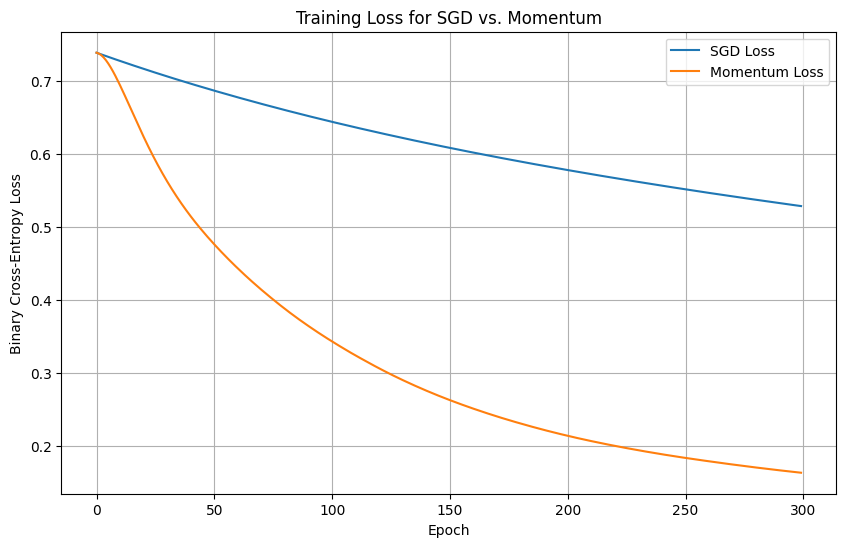

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
plt.plot(losses_sgd, label='SGD Loss')
plt.plot(losses_mom, label='Momentum Loss')
plt.title('Training Loss for SGD vs. Momentum')
plt.xlabel('Epoch')
plt.ylabel('Binary Cross-Entropy Loss')
plt.legend()
plt.grid(True)
plt.show()

**To-Do:** Plot both loss curves in one figure and compare the initial convergence rate. Explain in two sentences how momentum changes the trajectory.


## Exercise 3: Fine Tuning Activation Functions for an Image Classifier

**As stated in the exercise**  
Task: Experiment with different activation functions to optimize the performance of a convolutional neural network on an image dataset.  
Given data. A dataset of grayscale images of size 28 by 28 pixels with ten categories. A CNN architecture with two convolutional layers, one fully connected layer, and a softmax output layer. The ability to switch activation functions ReLU, Leaky ReLU, and Swish.  

Steps: Train the CNN using ReLU activation and record accuracy. Train the same CNN using Leaky ReLU and compare results. Train the CNN using Swish activation and analyze the effect. Evaluate model performance on test data for all cases. Interpret which activation function works best and why.

**Guidance**  
Use TensorFlow or Keras for this exercise so you focus on the activation comparison rather than low level convolution code. Implement a function that builds the same architecture with a parameter that chooses the activation layer. Ensure identical training settings across runs to isolate the activation effect.

**Learning point**  
Activations trade off sparsity, gradient flow, and smoothness. Leaky ReLU avoids dead neurons. Swish can improve accuracy at modest extra compute due to its smooth gating.



In [ ]:
# PREFILLED: just execute
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical

print("TensorFlow:", tf.__version__)
(x_train, y_train), (x_test, y_test) = mnist.load_data()
x_train = x_train.astype("float32")/255.0
x_test  = x_test.astype("float32")/255.0
x_train = np.expand_dims(x_train, -1)  # (N,28,28,1)
x_test  = np.expand_dims(x_test,  -1)
y_train_oh = to_categorical(y_train, 10)
y_test_oh  = to_categorical(y_test,  10)
x_train.shape, y_train_oh.shape

In [ ]:
# To-Do: implement build_cnn(activation_name) returning a compiled model
# Allowed activations: 'relu', 'leaky_relu', 'swish'
# Hints: use layers.LeakyReLU(alpha=0.1) and tf.nn.swish or layers.Activation('swish')
# def build_cnn(act='relu'):
#     inputs = layers.Input(shape=(28,28,1))
#     x = layers.Conv2D(32, 3, padding='same')(inputs)
#     if act == 'relu':
#         x = layers.ReLU()(x)
#     elif act == 'leaky_relu':
#         x = layers.LeakyReLU(alpha=0.1)(x)
#     elif act == 'swish':
#         x = layers.Activation('swish')(x)
#     else:
#         raise ValueError('unknown activation')
#     x = layers.MaxPooling2D()(x)
#     x = layers.Conv2D(64, 3, padding='same')(x)
#     # repeat activation choice
#     ...
#     x = layers.MaxPooling2D()(x)
#     x = layers.Flatten()(x)
#     x = layers.Dense(128)(x)
#     # final activation choice before classifier
#     ...
#     outputs = layers.Dense(10, activation='softmax')(x)
#     model = models.Model(inputs, outputs)
#     model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
#     return model


In [ ]:
# To-Do: train three models with identical epochs and batch size
# results = {}
# for act in ['relu','leaky_relu','swish']:
#     print(f"Training with {act}...")
#     model = build_cnn(act)
#     hist = model.fit(x_train, y_train_oh, validation_split=0.1, epochs=2, batch_size=128, verbose=2)
#     test_loss, test_acc = model.evaluate(x_test, y_test_oh, verbose=0)
#     results[act] = dict(test_acc=float(test_acc), history=hist.history)
# results


**To-Do:** Create a bar chart of test accuracy for each activation. Summarize in four sentences the trade offs observed.


## Conclusion

You implemented a deep network from scratch, optimized training with momentum, and compared activation functions in a CNN. For additional challenges, try implementing batch normalization or dropout for regularization, and compare their impact on convergence and accuracy.
